# Uji Statistik Perbandingan Klasifikasi RF vs SVM

**Alur:**
1. Load dataset training
2. Stratified K-Fold Cross Validation (k=10) untuk RF dan SVM
3. Uji normalitas (Shapiro-Wilk) pada nilai akurasi per fold
4. Uji statistik berpasangan (uji-t berpasangan atau Wilcoxon Signed-Rank)
5. Visualisasi hasil

**Jalankan sel secara berurutan: SEL 1 → 2 → 3 → 4 → 5**

## SEL 1 – Install dan import library

In [ ]:
!pip install scikit-learn==1.6.1 scipy joblib pandas numpy matplotlib seaborn --quiet
print('Install selesai.')

Install selesai.


## SEL 2 – Load dataset dan konfigurasi model

Upload file berikut ke Colab:
- Dataset_PIR.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# ================================================================
# SESUAIKAN nama file CSV dataset training di sini
# ================================================================
NAMA_FILE = 'Dataset_PIR.csv'
KOLOM_FITUR = ['count', 'durasi aktif', 'lag1', 'lag2', 'lag3',
               'lag4', 'lag5', 'lag6', 'avg30', 'avg60', 'delta1']
KOLOM_LABEL = 'label'
K_FOLD = 10

# Load dataset
df = pd.read_csv(NAMA_FILE)
df = df.dropna().reset_index(drop=True)

X = df[KOLOM_FITUR]
y = df[KOLOM_LABEL]

# Encode label jika masih teks
if y.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'Dataset dimuat: {X.shape[0]} baris, {X.shape[1]} fitur')
print(f'Distribusi label: {pd.Series(y).value_counts().to_dict()}')

Label encoding: {'rendah': np.int64(0), 'sedang': np.int64(1), 'tinggi': np.int64(2)}
Dataset dimuat: 1487 baris, 11 fitur
Distribusi label: {0: 701, 2: 483, 1: 303}


## SEL 3 – Stratified K-Fold Cross Validation (k=10)

In [ ]:
# Stratified K-Fold memastikan distribusi kelas seimbang di setiap fold
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=42)

# Pipeline RF (tidak perlu scaling)
pipeline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Pipeline SVM (perlu scaling via Pipeline)
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# Cross validation
print('Menjalankan 10-Fold Cross Validation...')
print('(Ini mungkin butuh beberapa detik)')

akurasi_rf  = cross_val_score(pipeline_rf,  X, y, cv=skf, scoring='accuracy')
akurasi_svm = cross_val_score(pipeline_svm, X, y, cv=skf, scoring='accuracy')

print('\n' + '='*60)
print('HASIL 10-FOLD CROSS VALIDATION')
print('='*60)
print(f'{'Fold':<6} {'RF Akurasi':>12} {'SVM Akurasi':>12}')
print('-'*32)
for i, (rf, svm) in enumerate(zip(akurasi_rf, akurasi_svm), 1):
    print(f'{i:<6} {rf*100:>11.2f}% {svm*100:>11.2f}%')
print('-'*32)
print(f'{'Rata-rata':<6} {akurasi_rf.mean()*100:>11.2f}% {akurasi_svm.mean()*100:>11.2f}%')
print(f'{'Std Dev':<6} {akurasi_rf.std()*100:>11.2f}% {akurasi_svm.std()*100:>11.2f}%')

Menjalankan 10-Fold Cross Validation...
(Ini mungkin butuh beberapa detik)

HASIL 10-FOLD CROSS VALIDATION
Fold     RF Akurasi  SVM Akurasi
--------------------------------
1           100.00%       90.60%
2           100.00%       90.60%
3           100.00%       91.95%
4           100.00%       87.92%
5           100.00%       91.28%
6           100.00%       89.26%
7           100.00%       89.93%
8           100.00%       90.54%
9           100.00%       94.59%
10           99.32%       89.86%
--------------------------------
Rata-rata       99.93%       90.65%
Std Dev        0.20%        1.68%


## SEL 4 – Uji normalitas dan uji statistik berpasangan

In [ ]:
# Uji normalitas Shapiro-Wilk pada nilai akurasi per fold
stat_rf,  p_rf  = stats.shapiro(akurasi_rf)
stat_svm, p_svm = stats.shapiro(akurasi_svm)

print('='*60)
print('UJI NORMALITAS – SHAPIRO-WILK')
print('='*60)
print(f'RF  - Statistik: {stat_rf:.4f} | p-value: {p_rf:.6f}')
print(f'SVM - Statistik: {stat_svm:.4f} | p-value: {p_svm:.6f}')
print()
if p_rf > 0.05:
    print('RF  → Distribusi NORMAL (p > 0.05)')
else:
    print('RF  → Distribusi TIDAK NORMAL (p < 0.05)')
if p_svm > 0.05:
    print('SVM → Distribusi NORMAL (p > 0.05)')
else:
    print('SVM → Distribusi TIDAK NORMAL (p < 0.05)')

print()
print('='*60)
print('UJI STATISTIK BERPASANGAN RF vs SVM')
print('='*60)
print('Catatan: Uji berpasangan digunakan karena nilai akurasi')
print('per fold berasal dari data yang sama (berpasangan)')
print()

if p_rf > 0.05 and p_svm > 0.05:
    # Kedua normal → uji-t berpasangan
    print('Metode: UJI-T BERPASANGAN (Paired t-test)')
    print('Hipotesis:')
    print('  H0: Tidak ada perbedaan signifikan akurasi RF dan SVM')
    print('  H1: Terdapat perbedaan signifikan akurasi RF dan SVM')
    print()
    t_stat, p_value = stats.ttest_rel(akurasi_rf, akurasi_svm)
    print(f'Statistik t : {t_stat:.4f}')
    print(f'p-value     : {p_value:.6f}')
else:
    # Tidak normal → Wilcoxon Signed-Rank
    print('Metode: WILCOXON SIGNED-RANK')
    print('Hipotesis:')
    print('  H0: Tidak ada perbedaan signifikan akurasi RF dan SVM')
    print('  H1: Terdapat perbedaan signifikan akurasi RF dan SVM')
    print()
    w_stat, p_value = stats.wilcoxon(akurasi_rf, akurasi_svm)
    print(f'Statistik W : {w_stat:.4f}')
    print(f'p-value     : {p_value:.6f}')

print()
ALPHA = 0.05
if p_value < ALPHA:
    print(f'Kesimpulan: p-value ({p_value:.6f}) < α ({ALPHA})')
    print('→ H0 DITOLAK: Terdapat perbedaan yang SIGNIFIKAN')
    print('  antara akurasi klasifikasi RF dan SVM')
else:
    print(f'Kesimpulan: p-value ({p_value:.6f}) > α ({ALPHA})')
    print('→ H0 DITERIMA: Tidak terdapat perbedaan yang signifikan')
    print('  antara akurasi klasifikasi RF dan SVM')

UJI NORMALITAS – SHAPIRO-WILK
RF  - Statistik: 0.3657 | p-value: 0.000000
SVM - Statistik: 0.9236 | p-value: 0.388202

RF  → Distribusi TIDAK NORMAL (p < 0.05)
SVM → Distribusi NORMAL (p > 0.05)

UJI STATISTIK BERPASANGAN RF vs SVM
Catatan: Uji berpasangan digunakan karena nilai akurasi
per fold berasal dari data yang sama (berpasangan)

Metode: WILCOXON SIGNED-RANK
Hipotesis:
  H0: Tidak ada perbedaan signifikan akurasi RF dan SVM
  H1: Terdapat perbedaan signifikan akurasi RF dan SVM

Statistik W : 0.0000
p-value     : 0.001953

Kesimpulan: p-value (0.001953) < α (0.05)
→ H0 DITOLAK: Terdapat perbedaan yang SIGNIFIKAN
  antara akurasi klasifikasi RF dan SVM


## SEL 5 – Visualisasi hasil cross validation

/tmp/ipykernel_2058/3331468719.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Model', y='Akurasi (%)',


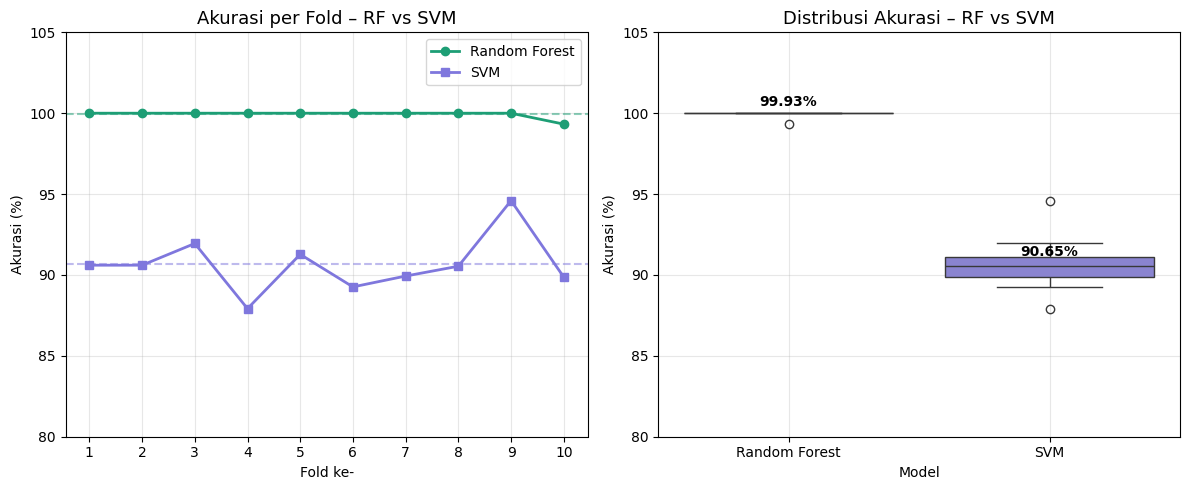

Gambar disimpan: kfold_rf_vs_svm.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot akurasi per fold
ax1 = axes[0]
folds = range(1, K_FOLD + 1)
ax1.plot(folds, akurasi_rf*100,  'o-', color='#1D9E75', label='Random Forest', linewidth=2)
ax1.plot(folds, akurasi_svm*100, 's-', color='#7F77DD', label='SVM', linewidth=2)
ax1.axhline(akurasi_rf.mean()*100,  color='#1D9E75', linestyle='--', alpha=0.5)
ax1.axhline(akurasi_svm.mean()*100, color='#7F77DD', linestyle='--', alpha=0.5)
ax1.set_xlabel('Fold ke-')
ax1.set_ylabel('Akurasi (%)')
ax1.set_title('Akurasi per Fold – RF vs SVM', fontsize=13)
ax1.set_xticks(folds)
ax1.legend()
ax1.set_ylim(80, 105)
ax1.grid(alpha=0.3)

# Boxplot perbandingan akurasi
ax2 = axes[1]
data_plot = pd.DataFrame({
    'Akurasi (%)': np.concatenate([akurasi_rf*100, akurasi_svm*100]),
    'Model': ['Random Forest']*K_FOLD + ['SVM']*K_FOLD
})
sns.boxplot(data=data_plot, x='Model', y='Akurasi (%)',
            palette=['#1D9E75', '#7F77DD'], ax=ax2)
ax2.set_title('Distribusi Akurasi – RF vs SVM', fontsize=13)
ax2.set_ylabel('Akurasi (%)')
ax2.set_ylim(80, 105)
ax2.grid(alpha=0.3)

# Tambah label rata-rata
for i, (model, val) in enumerate([('Random Forest', akurasi_rf.mean()*100),
                                   ('SVM', akurasi_svm.mean()*100)]):
    ax2.text(i, val + 0.5, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kfold_rf_vs_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: kfold_rf_vs_svm.png')